In [1]:
import numpy as np
from matplotlib import pyplot as plt
import kwant
import kwant.continuum
# from pfapack import pfaffian as pf
import pfaffian as pff

# import scipy
# import pfaffian as pff
import pylab as py
import numpy.linalg as npl
#import ipywidgets
# from tqdm.auto import tqdm
# import scienceplots
# plt.style.use('science')



c:\Users\Laura\anaconda3new\envs\myperfectenv\Lib\site-packages\kwant\solvers\default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


In [2]:
# pyplot.ion()
pi = np.pi

sigma_0 = np.eye(2)
sigma_x = np.array(
    [[0, 1],
     [1, 0]])
sigma_y = np.array(
    [[0, -1j],
     [1j, 0]])
sigma_z = np.array(
    [[1, 0],
     [0, -1]])
params = dict(kappa=0.9, W=0, num_reals=100)

In [17]:
lat = kwant.lattice.square(norbs = 4)

In [18]:
def system_2DBHZ_d(length, width, p):
    ''' l i s m'''
    def onsite(site):
        return p['m'] * np.kron(sigma_0,sigma_z)   + 0.1*np.kron(sigma_0,sigma_0)

    def hop_x(site0, site1):
        return (-p['tss']*np.kron(sigma_0,sigma_z)/2 + p['tsp'] * np.kron(sigma_z,sigma_x)/2j)

    def	hop_y(site0, site1):
        return (-p['tss']*np.kron(sigma_0,sigma_z)/2 + p['tsp'] * np.kron(sigma_0,sigma_y)/2j)

    def hop_pbc_y(site0, site1):
        return p['pbc']*hop_y(site0,site1)
    def hop_pbc_x(site0, site1):
        return p['pbc']*hop_x(site0,site1)
                                     
    sys = kwant.Builder()

    sys[(lat(x, y) for x in range(-length,length) for y in range(-width,width))] = onsite        
    sys[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
    sys[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y
    # for x in range(-(length),length-1):
    #            sys[lat(x, -(width)), lat(x, width-1)] = onsite  
    #            sys[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
    # for y in range(-(width),width-1):
    #            sys[lat(-(length), y), lat(length-1, y)] = onsite
    #            sys[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y  

    return sys 

### Helper functions

In [19]:
def spectrum(sys):
    fsys = sys.finalized() 
    h = fsys.hamiltonian_submatrix(params = p)
    evals, evecs = np.linalg.eigh(h)
    plt.figure(figsize=(8,5));
    py.scatter(range(len(evals)), evals)
    py.xlabel('Index')
    py.ylabel('Energy')
    py.show()

In [20]:
def find_nonzero(A):
    for i in range(np.shape(A)[0]):
        for j in range(np.shape(A)[1]):
            if A[i,j] != 0:
                return i,j
    return

In [21]:
def pos_H(fsyst, coord=0):
    """ Calculate the position operator in the 'coord' direction of the          
    Hamiltonian of fsyst. It also computes the position operator for a given position with index=index_origin in fsyst.sites
    """
    H, ton, fon = fsyst.hamiltonian_submatrix(return_norb=True)
    x = np.zeros(H.shape)
    ind = 0

    for i in range(len(fsyst.sites)):
        for j in range(ind, ind + ton[i]):

            x[j, j] =  fsyst.sites[i].pos[coord]
            # x0[j, j] = fsyst.sites[index_origin].pos[coord]
        ind += ton[i]

    return x
import time,sys



def update_progress(progress, decimalpoints=0):
    """ Make an interactive progress bar as described on:
    https://stackoverflow.com/questions/3160699/python-progress-bar
    """
    barLength = 20 # Modify this to change the length of the progress bar
    status = ""
    if isinstance(progress, int):
        progress = float(progress)
    if not isinstance(progress, float):
        progress = 0
        status = "error: progress var must be float\r\n"
    if progress < 0:
        progress = 0
        status = "Halt...\r\n"
    if progress >= 1:
        progress = 1
        status = "Done...\r\n"
    block = int(round(barLength*progress))
    text = "\rPercent: [{0}] {1}% {2}".format( "#"*block + 
            "-"*(barLength-block), round(progress*100, decimalpoints), status)
    sys.stdout.write(text)
    sys.stdout.flush()  


In [13]:
def spectral_localizer_AII2D(syst,p=params,X0=np.array([5,5]),Ls=10):

    '''Computes the spectral localizer for a 2D AII system.
    ----------------
    syst: kwant object non-finalized, 
  
    Returns
    ----------------
    pfaff_sign: Topological invariant as the sign of the pfaffian.'''
    p = {**params, **p} 


    W = p['W']
    kappa = p['kappa']
    num_reals = p['num_reals']
    E0 = p['E0']
    fsyst = syst.finalized()
    ham = fsyst.hamiltonian_submatrix()

    x0,y0=X0

    X= pos_H(fsyst,coord=0)
    Y= pos_H(fsyst,coord=1)
    zer = np.zeros(np.shape(ham))
    id = np.identity(np.shape(ham)[0])

    D = (X-(x0+0.2)*id)+1j*(Y-(y0+0.2)*id)
    TR = np.kron(np.kron(np.identity(Ls*Ls),sigma_y),sigma_0)
    Q = (1/np.sqrt(2))*np.block([[id,TR],
                                 [-TR,id]])
    
    seed_range = np.linspace(0,30,num_reals)
    pfaffian_realizations = 0

    if W!=0: 

        print('Averaging over realizations...')
        for ind,val in enumerate(seed_range):
            update_progress((ind+1)/len(seed_range))

            seed = val
            np.random.seed(int(seed))
            disp = np.diag(np.random.uniform(low=-W/2,high=W/2,size=len(fsyst.sites)))
            AND_disorder = np.kron(disp,np.eye(4))
            h = ham - E0*id + AND_disorder
            L= np.block([[h,kappa*np.conjugate(D)],
                 [kappa*D,-h]])

            Hp = 1j*np.conjugate(Q)@L@Q  #lorings section 5.4 i*conj(Q).H.Q

            pfaff_sign = pff.pfaffian(Hp,sign_only=True)
            pfaffian_realizations = pfaffian_realizations + np.real(pfaff_sign)
            print('Realization Pfaffian:',np.real(pfaff_sign))

        pfaffian_averaged = pfaffian_realizations/num_reals
        print('Pfaffian sign:',pfaffian_averaged)

    else: 
        h = ham - E0*id
        L= np.block([[h,kappa*np.conjugate(D)],
                    [kappa*D,-h]])

        Hp = 1j*np.conjugate(Q)@L@Q  #lorings section 5.4 i*conj(Q).H.Q
        print((Hp.imag).max())
        
        pfaffian_averaged = np.real(pff.pfaffian(Hp,sign_only=True))

        print('Pfaffian sign:',pfaffian_averaged)

    return pfaffian_averaged

In [14]:
def spectral_localizer_AII2D_schultz(syst,kappa,E0,X0=np.array([5,5]),Ls=10):

    '''Computes the spectral localizer for a 2D AII system.
    ----------------
    syst: kwant object non-finalized, 
  
    Returns
    ----------------
    pfaff_sign: Topological invariant as the sign of the pfaffian.'''
    
    fsyst = syst.finalized()
    ham = fsyst.hamiltonian_submatrix()

    reham = (1/2)*(ham+np.conjugate(ham))
    imham = (1/2j)*(ham-np.conjugate(ham))

    x0,y0=X0

    X= pos_H(fsyst,coord=0)
    Y= pos_H(fsyst,coord=1)
    id = np.identity(np.shape(ham)[0])

    Xt = (X-(x0+0.)*id)
    Yt = (Y-(y0+0.)*id)
    TR = np.kron(np.kron(np.identity(Ls*Ls),1j*sigma_y),sigma_0)
 
    print(find_nonzero((TR.T)@np.conjugate(ham)@TR-ham))


    L= np.block([[imham + kappa*Xt@TR,reham@TR+kappa*Yt],
                 [TR@reham-kappa*Yt,imham-kappa*Xt@TR]])

    

    pfaff_sign = pff.pfaffian(L,sign_only=True)

    print('Pfaffian sign:',np.real(pfaff_sign))

    return pfaff_sign

In [24]:
def norm(syst,length=3,E0=0.,X0=np.array([5,5]),Ls=10):

    '''Computes the spectral localizer for a 2D AII system.
    ----------------
    syst: kwant object non-finalized, 
  
    Returns
    ----------------
    pfaff_sign: Topological invariant as the sign of the pfaffian.'''
    
    fsyst = syst.finalized()
    ham = fsyst.hamiltonian_submatrix()

    x0,y0=X0

    X= pos_H(fsyst,coord=0)
    Y= pos_H(fsyst,coord=1)
    zer = np.zeros(np.shape(ham))
    id = np.identity(np.shape(ham)[0])

    D = (X-(x0+0.2)*id)+1j*(Y-(y0+0.2)*id)
    # TR = np.kron(np.kron(np.identity(Ls*Ls),sigma_y),sigma_0)
    # Q = (1/np.sqrt(2))*np.block([[id,TR],
    #                              [-TR,id]])

    g = 1.0/(np.linalg.norm(np.linalg.inv(ham-E0*id),ord=2))
    # g = np.linalg.norm(ham,ord=2) # band width    
    kappa_min = 2*g/length
    print(g,length)

    kappa_max = g**3/(np.linalg.norm(ham,ord=2)*np.linalg.norm(D@ham-ham@D,ord=2))
    print ('kappa_max=',kappa_max, 'kappa_min=',kappa_min)
    return 

## Bands and Localizer

In [25]:
length=7
p = dict(m = 4.0, tss = 1, tsp =1,pbc=0)
syst = system_2DBHZ_d(length, length, p)
kappcalc = norm(syst,length,0.1,X0=np.array([0,0]),Ls=2*length)
# kappcalc

2.0608169142811996 7
kappa_max= 0.7219829733089146 kappa_min= 0.5888048326517713


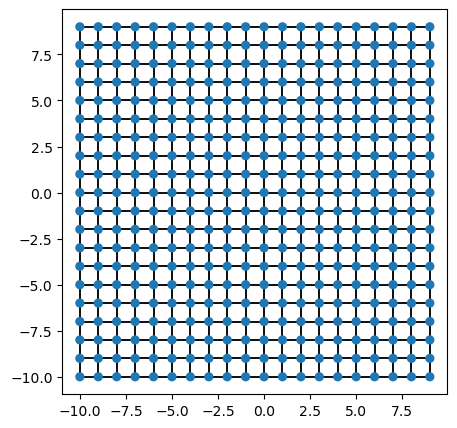

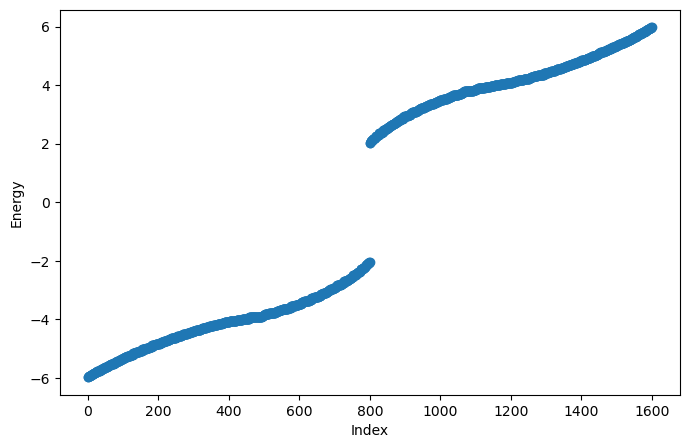

In [13]:
length=10
p = dict(m = 4., tss = 1, tsp =1)
syst = system_2DBHZ_d(length, length, p)
kwant.plot(syst,fig_size=(8,5))
spectrum(syst)

In [29]:
length=7
p = dict(m = 0.3, tss = 1, tsp =1)
syst = system_2DBHZ_d(length, length, p)
kap = 0.2
det = spectral_localizer_AII2D(syst,p,X0=np.array([0,0]),Ls=2*length);

0.0
Pfaffian sign: -1.0


In [14]:
length=7
p = dict(m = 0.3, tss = 1, tsp =1)
kap = 0.2
syst = system_2DBHZ_d(length, length, p)
det = spectral_localizer_AII2D_schultz(syst,kap,0.0,X0=np.array([0,0]),Ls=2*length);

UserCodeError: Error occurred in user-supplied value function "onsite".
See the upper part of the above backtrace for more information.

In [35]:
#phase transition is at |M/t|=2
m_vals = np.linspace(-3,3,20)
dets = []
Len=5
p = dict(m = 4., tss = 1, tsp =1,kappa = 0.9)


for m in m_vals:
    p['m'] = m
    syst = system_2DBHZ_d(Len, Len, p)    
    # det = spectral_localizer_AII2D(syst,0.2,0.0,X0=np.array([0,0]),Ls=2*Len);
    det = spectral_localizer_AII2D(syst,p,X0=np.array([0,0]),Ls=2*Len);
    print(m, det)
    dets.append(det)

Pfaffian sign: 1.0
-3.0 1.0
Pfaffian sign: 1.0
-2.6842105263157894 1.0
Pfaffian sign: 1.0
-2.3684210526315788 1.0
Pfaffian sign: 1.0
-2.0526315789473686 1.0
Pfaffian sign: 1.0
-1.736842105263158 1.0
Pfaffian sign: -1.0
-1.4210526315789473 -1.0
Pfaffian sign: -1.0
-1.105263157894737 -1.0
Pfaffian sign: -1.0
-0.7894736842105265 -1.0
Pfaffian sign: -1.0
-0.47368421052631593 -1.0
Pfaffian sign: -1.0
-0.1578947368421053 -1.0
Pfaffian sign: -1.0
0.1578947368421053 -1.0
Pfaffian sign: -1.0
0.4736842105263155 -1.0
Pfaffian sign: -1.0
0.7894736842105261 -1.0
Pfaffian sign: -1.0
1.1052631578947363 -1.0
Pfaffian sign: -1.0
1.421052631578947 -1.0
Pfaffian sign: 1.0
1.7368421052631575 1.0
Pfaffian sign: 1.0
2.052631578947368 1.0
Pfaffian sign: 1.0
2.3684210526315788 1.0
Pfaffian sign: 1.0
2.6842105263157894 1.0
Pfaffian sign: 1.0
3.0 1.0


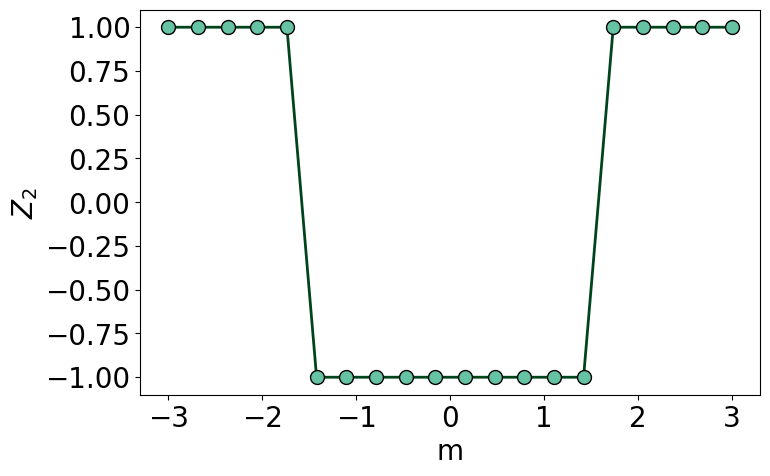

In [37]:
cmap = plt.get_cmap('BuGn')
plt.figure(figsize=(8,5));
plt.plot(m_vals,dets,'o-',markersize=10,linewidth=2,markeredgecolor='k',markerfacecolor=cmap(0.5),color=cmap(1.))
plt.xlabel('m',fontsize=20)
plt.ylabel('$Z_2$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [50]:
L_vals = np.linspace(-10,10,20)
dets = []
Len=7
p['m'] = 0.5
for L in L_vals:
    syst = system_2DBHZ_d(Len, Len, p)    
    det = spectral_localizer_AII2D(syst,0.2,0.0,X0=np.array([L,0]),Ls=2*Len);
    print(L, det)
    dets.append(det)

Pfaffian: (1+0j)
-10.0 (1+0j)
Pfaffian: (1+0j)
-8.947368421052632 (1+0j)
Pfaffian: (1+0j)
-7.894736842105264 (1+0j)
Pfaffian: (1+0j)
-6.842105263157895 (1+0j)
Pfaffian: (-1+0j)
-5.7894736842105265 (-1+0j)
Pfaffian: (-1+0j)
-4.736842105263158 (-1+0j)
Pfaffian: (-1+0j)
-3.6842105263157894 (-1+0j)
Pfaffian: (-1+0j)
-2.6315789473684212 (-1+0j)
Pfaffian: (-1+0j)
-1.578947368421053 (-1+0j)
Pfaffian: (-1+0j)
-0.526315789473685 (-1+0j)
Pfaffian: (-1+0j)
0.5263157894736832 (-1+0j)
Pfaffian: (-1+0j)
1.5789473684210513 (-1+0j)
Pfaffian: (-1+0j)
2.6315789473684212 (-1+0j)
Pfaffian: (-1+0j)
3.6842105263157894 (-1+0j)
Pfaffian: (-1+0j)
4.7368421052631575 (-1+0j)
Pfaffian: (1+0j)
5.789473684210526 (1+0j)
Pfaffian: (1+0j)
6.842105263157894 (1+0j)
Pfaffian: (1+0j)
7.894736842105264 (1+0j)
Pfaffian: (1+0j)
8.94736842105263 (1+0j)
Pfaffian: (1+0j)
10.0 (1+0j)


/Users/adolfo/miniforge3/envs/kwant-bismuth/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/adolfo/miniforge3/envs/kwant-bismuth/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


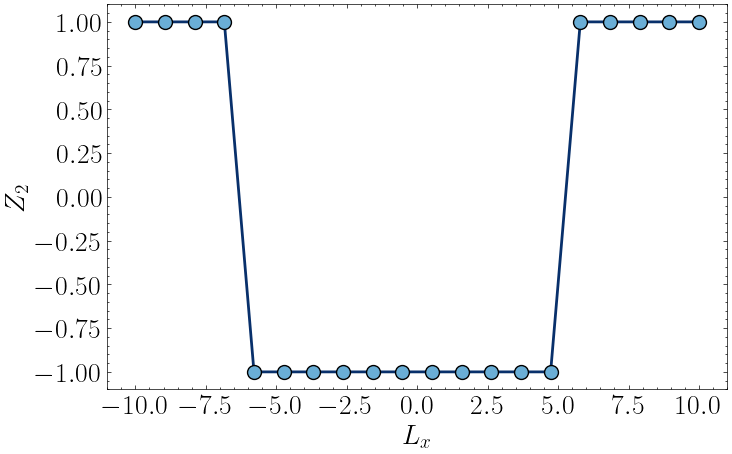

In [52]:
cmap = plt.get_cmap('Blues')
plt.figure(figsize=(8,5));
plt.plot(L_vals,dets,'o-',markersize=10,linewidth=2,markeredgecolor='k',markerfacecolor=cmap(0.5),color=cmap(1.))
plt.xlabel('$L_x$',fontsize=20)
plt.ylabel('$Z_2$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

## Compare to Bi

In [150]:
import numpy as np
from matplotlib import pyplot as plt
import kwant
import kwant.continuum
# from pfapack import pfaffian as pf
import pfaffian as pff
import scipy.linalg as spl
# import scipy
# import pfaffian as pff
import pylab as py
import numpy.linalg as npl

import scienceplots
#import ipywidgets
# from tqdm.auto import tqdm
# import scienceplots
# plt.style.use('science')

# pyplot.ion()
pi = np.pi

sigma_0 = np.eye(2)
sigma_x = np.array(
    [[0, 1],
     [1, 0]])
sigma_y = np.array(
    [[0, -1j],
     [1j, 0]])
sigma_z = np.array(
    [[1, 0],
     [0, -1]])

params = dict(E0=0, kappa=0.9, W=0, num_reals=100)


lat = kwant.lattice.square(norbs = 4)
# "Topological Anderson insulator phenomena,Yanxia Xing,1,2 Lei Zhang,2 and Jian Wang2,*""

def system_2DBHZ_d(length, width, p):
    ''' l i s m'''

    print('m/2B:',p['m'])
    def onsite(site):
        return (p['m'] - 4*p['B'])* np.kron(sigma_z,sigma_0)   + 0.1*np.kron(sigma_0,sigma_0)

    def hop_x(site0, site1):
        return (p['B']*np.kron(sigma_z,sigma_0) + p['A'] * np.kron(sigma_x,sigma_z)/2j)

    def	hop_y(site0, site1):
        return (p['B']*np.kron(sigma_z,sigma_0) - p['A'] * np.kron(sigma_y,sigma_0)/2j)

    def hop_pbc_y(site0, site1):
        return p['pbc']*hop_y(site0,site1)
    def hop_pbc_x(site0, site1):
        return p['pbc']*hop_x(site0,site1)
                                     
    sys = kwant.Builder()

    sys[(lat(x, y) for x in range(-length,length) for y in range(-width,width))] = onsite        
    sys[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
    sys[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y
    # for x in range(-(length),length-1):
    #            sys[lat(x, -(width)), lat(x, width-1)] = onsite  
    #            sys[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
    # for y in range(-(width),width-1):
    #            sys[lat(-(length), y), lat(length-1, y)] = onsite
    #            sys[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y  

    return sys 

def pos_H(fsyst, coord=0):
    """ Calculate the position operator in the 'coord' direction of the          
    Hamiltonian of fsyst. It also computes the position operator for a given position with index=index_origin in fsyst.sites
    """
    H, ton, fon = fsyst.hamiltonian_submatrix(return_norb=True)
    x = np.zeros(H.shape)
    ind = 0

    for i in range(len(fsyst.sites)):
        for j in range(ind, ind + ton[i]):

            x[j, j] =  fsyst.sites[i].pos[coord]
            # x0[j, j] = fsyst.sites[index_origin].pos[coord]
        ind += ton[i]

    return x
import time,sys



def update_progress(progress, decimalpoints=0):
    """ Make an interactive progress bar as described on:
    https://stackoverflow.com/questions/3160699/python-progress-bar
    """
    barLength = 20 # Modify this to change the length of the progress bar
    status = ""
    if isinstance(progress, int):
        progress = float(progress)
    if not isinstance(progress, float):
        progress = 0
        status = "error: progress var must be float\r\n"
    if progress < 0:
        progress = 0
        status = "Halt...\r\n"
    if progress >= 1:
        progress = 1
        status = "Done...\r\n"
    block = int(round(barLength*progress))
    text = "\rPercent: [{0}] {1}% {2}".format( "#"*block + 
            "-"*(barLength-block), round(progress*100, decimalpoints), status)
    sys.stdout.write(text)
    sys.stdout.flush()  


def flattened_H(H):

    evals,U = spl.eigh(H)
    D = np.diag(evals)
    M = U@np.sign(D)@spl.inv(U)

    return M

def spectral_localizer_AII2D(syst,p=params,X0=np.array([5,5]),Ls=10,flatten=False):

    '''Computes the spectral localizer for a 2D AII system.
    ----------------
    syst: kwant object non-finalized, 
  
    Returns
    ----------------
    pfaff_sign: Topological invariant as the sign of the pfaffian.'''
    p = {**params, **p} 


    W = p['W']
    kappa = p['kappa']
    num_reals = p['num_reals']
    E0 = p['E0']
    x0,y0=X0

    print('E0:',E0,'x0,y0:',x0,y0,'kappa:',kappa,'W:',W)

    fsyst = syst.finalized()
    ham = fsyst.hamiltonian_submatrix()

    if flatten==True:
        ham = flattened_H(ham)



    x0,y0=X0

    X= pos_H(fsyst,coord=0)
    Y= pos_H(fsyst,coord=1)
    zer = np.zeros(np.shape(ham))
    id = np.identity(np.shape(ham)[0])

    D = (X-(x0+0.2)*id)+1j*(Y-(y0+0.2)*id)
    TR = np.kron(np.kron(np.identity(Ls*Ls),sigma_0),sigma_y)
    Q = (1/np.sqrt(2))*np.block([[id,TR],
                                 [-TR,id]])
    
    seed_range = np.linspace(0,30,num_reals)
    pfaffian_realizations = 0

    if W!=0: 

        print('Averaging over realizations...')
        for ind,val in enumerate(seed_range):
            update_progress((ind+1)/len(seed_range))

            seed = val
            np.random.seed(int(seed))
            disp = np.diag(np.random.uniform(low=-W/2,high=W/2,size=len(fsyst.sites)))
            AND_disorder = np.kron(disp,np.eye(4))
            h = ham - E0*id + AND_disorder
            L= np.block([[h,kappa*np.conjugate(D)],
                 [kappa*D,-h]])

            Hp = 1j*np.conjugate(Q)@L@Q  #lorings section 5.4 i*conj(Q).H.Q

            pfaff_sign = pff.pfaffian(Hp,sign_only=True)
            pfaffian_realizations = pfaffian_realizations + np.real(pfaff_sign)
            print('Realization Pfaffian:',np.real(pfaff_sign))

        pfaffian_averaged = pfaffian_realizations/num_reals
        print('Pfaffian sign:',pfaffian_averaged)

    else: 
        h = ham - E0*id
        L= np.block([[h,kappa*np.conjugate(D)],
                    [kappa*D,-h]])

        Hp = 1j*np.conjugate(Q)@L@Q  #lorings section 5.4 i*conj(Q).H.Q
        print((Hp.imag).max())
        
        pfaffian_averaged = np.real(pff.pfaffian(Hp,sign_only=True))

        print('Pfaffian sign:',pfaffian_averaged)

    return pfaffian_averaged

from matplotlib import cm


def Plot_DOS_2D(Emin,Emax, fsyst, evals,evecs,p=params):
        '''Function for plotting wf within Emin,Emax'''
        p = {**params, **p} 

        norbs = p['norbs']
        positions_wf= []
        number_of_states=0
        wf=np.zeros((len(evals)), dtype = 'float')

        for i in range(len(evals)):
                if Emin<evals[i]<Emax: 
                        number_of_states=number_of_states+1
                        positions_wf.append(i)
                        wf[:] = wf[:]+ abs(evecs[:,i])**2
                        print(i,evals[i])

        wf = wf/number_of_states

        print(wf.max(),np.log(wf.max()))
        def site_size(k):
                site_size=0
                for j in range(k*norbs,k*norbs+norbs):
                        # site_size= (20* wf[j] / wf.max())+ site_size
                    site_size= 20*( np.abs(np.log(wf.max()))-np.abs(np.log(wf[j]/wf.max()))) + site_size
                return site_size
        
        X, Y, sizes = [], [], []

        for ind, site in enumerate(fsyst.sites):
            x,y = site.pos
            X.append(x)
            Y.append(y)
            aux = site_size(ind) 
            sizes.append(aux)
        #kwant.plot(fsyst)
        #kwant.plot(fsyst,site_lw=0, site_size=site_size, site_color=(0, 0, 1, 0.3),hop_lw=0.0);

        #OPTION 1: IMPORT FIGURE TO HTML

        # import plotly.express as px
        # fig=px.scatter_3d( x=np.array(X, dtype=object), y=np.array(Y, dtype=object), z=np.array(Z, dtype=object),size=sizes,color=(np.array(sizes)/np.max(sizes)), color_continuous_scale=px.colors.sequential.Blues,opacity=0.5)
        # fig.show()
        # fig.write_html("ap 5.1 h 12.5 HDOWN 1.5 energy -0.05 0.05.html")

        #OPTION 2: SEE THE PLOT IN A WINDOW

        fig = py.figure(figsize=(7,7))
        ax = fig.add_subplot()
        #ax.scatter(X, Y, Z, s=sizes, c=np.array(sizes)/np.max(sizes), alpha=0.5)
        ax.scatter(X, Y, s=sizes, c=(np.array(sizes)/np.max(sizes)), cmap = cm.RdPu, alpha=0.5)
        ax.set_xlabel('x_pos')
        ax.set_ylabel('y_pos')
        py.show()
        
        print("The number of states in this range is",number_of_states)
        #return fsyst, sizes       

  


### Topological


In [2]:
1.5/5

0.3

In [65]:
#phase transition is at |M/t|=2
m_vals = np.linspace(-1,10,20)
dets = []
Len=5
p = dict(m = 4., B = 1, A =1,kappa = 0.1)

for m in m_vals:
    p['m'] = m
    syst = system_2DBHZ_d(Len, Len, p)    

    det = spectral_localizer_AII2D(syst,p,X0=np.array([0,0]),Ls=2*Len);

    dets.append(det)

    
    

m/2B: -1.0
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: -0.42105263157894735
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 0.1578947368421053
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 0.736842105263158
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 1.3157894736842106
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 1.8947368421052633
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 2.473684210526316
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 3.052631578947368
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 3.6315789473684212
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 4.210526315789474
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 4.7894736842105265
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 5.368421052631579
E0: 0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 5.947368421052632


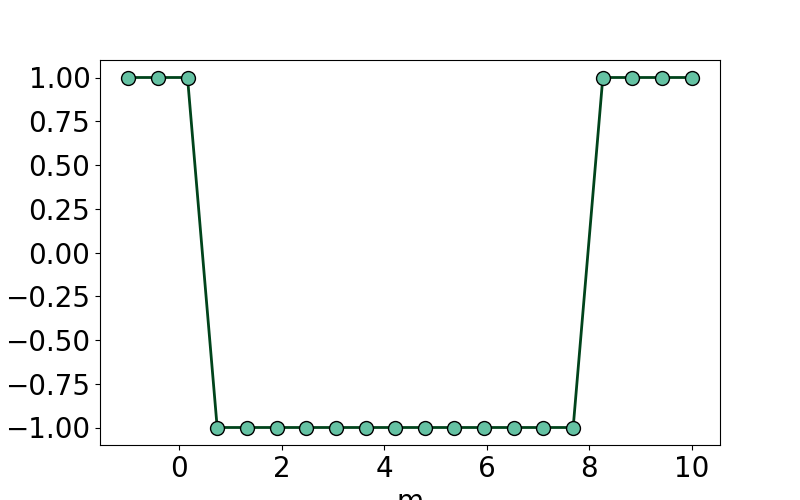

In [66]:
%matplotlib widget
cmap = plt.get_cmap('BuGn')
plt.figure(figsize=(8,5));
plt.plot(m_vals,dets,'o-',markersize=10,linewidth=2,markeredgecolor='k',markerfacecolor=cmap(0.5),color=cmap(1.))
plt.xlabel('m',fontsize=20)
plt.ylabel('$Z_2$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

#### Z2 vs E

Let us see how it changes with E for m=0.5

In [45]:
#phase transition is at |M/t|=2


Er = np.linspace(-6,6,20)
dets = []
Len=5
m = 2.5

p = dict(m = 2.5, B = 1, A =1,kappa = 0.1)




for E0 in Er:
    p['E0'] = E0
    
    syst = system_2DBHZ_d(Len, Len, p)    

    det = spectral_localizer_AII2D(syst,p,X0=np.array([0,0]),Ls=2*Len);

    dets.append(det)

    
    

m/2B: 2.5
E0: -6.0 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 2.5
E0: -5.368421052631579 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 2.5
E0: -4.7368421052631575 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 2.5
E0: -4.105263157894737 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 2.5
E0: -3.473684210526316 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 2.5
E0: -2.8421052631578947 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 2.5
E0: -2.210526315789474 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 2.5
E0: -1.578947368421053 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: 1.0
m/2B: 2.5
E0: -0.9473684210526319 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 2.5
E0: -0.3157894736842106 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 2.5
E0: 0.3157894736842106 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0
m/2B: 2.5
E0: 0.947368421052631 x0,y0: 0 0 kappa: 0.1 W: 0
-0.0
Pfaffian sign: -1.0

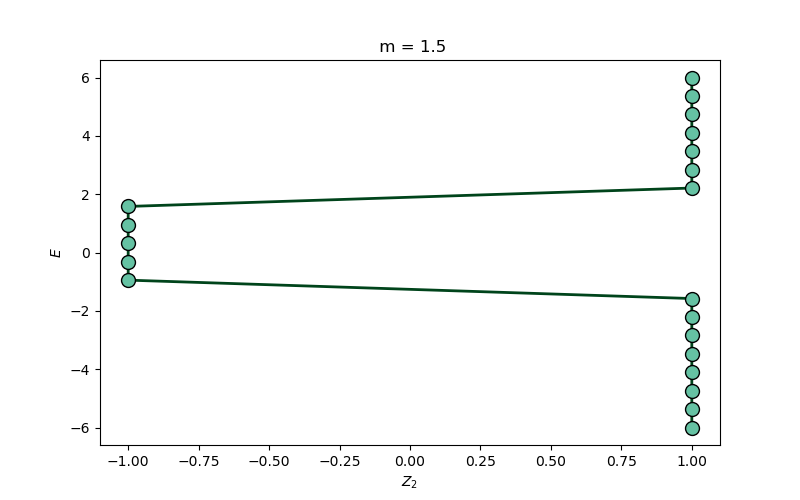

In [46]:
%matplotlib widget
cmap = plt.get_cmap('BuGn')
plt.figure(figsize=(8,5));
plt.plot(dets,Er,'o-',markersize=10,linewidth=2,markeredgecolor='k',markerfacecolor=cmap(0.5),color=cmap(1.))
plt.xlabel('$Z_2$',fontsize=10)
plt.ylabel('$E$',fontsize=10)
plt.xticks(fontsize=10)
plt.title(' m = 1.5')
plt.yticks(fontsize=10)
plt.show()

#### Flattened Hamiltonian

Now Eg = 2. kappa = 2/5 = 0.4?


In [47]:
#phase transition is at |M/t|=2


Er = np.linspace(-6,6,20)
dets = []
Len=5
m = 2.5

p = dict(m =m, A=1,B=1,num_reals=20,W=0 ,kappa=0.35)



for E0 in Er:
    p['E0'] = E0
    
    syst = system_2DBHZ_d(Len, Len, p)    

    det = spectral_localizer_AII2D(syst,p,X0=np.array([0,0]),Ls=2*Len,flatten=True);

    dets.append(det)

    
    

m/2B: 2.5
E0: -6.0 x0,y0: 0 0 kappa: 0.35 W: 0
1.7763568394002505e-15
Pfaffian sign: 1.0
m/2B: 2.5
E0: -5.368421052631579 x0,y0: 0 0 kappa: 0.35 W: 0
1.6044023748440495e-15
Pfaffian sign: 1.0
m/2B: 2.5
E0: -4.7368421052631575 x0,y0: 0 0 kappa: 0.35 W: 0
1.6044023748440495e-15
Pfaffian sign: 1.0
m/2B: 2.5
E0: -4.105263157894737 x0,y0: 0 0 kappa: 0.35 W: 0
1.7763568394002505e-15
Pfaffian sign: 1.0
m/2B: 2.5
E0: -3.473684210526316 x0,y0: 0 0 kappa: 0.35 W: 0
1.7763568394002505e-15
Pfaffian sign: 1.0
m/2B: 2.5
E0: -2.8421052631578947 x0,y0: 0 0 kappa: 0.35 W: 0
1.6044023748440495e-15
Pfaffian sign: 1.0
m/2B: 2.5
E0: -2.210526315789474 x0,y0: 0 0 kappa: 0.35 W: 0
1.6044023748440495e-15
Pfaffian sign: 1.0
m/2B: 2.5
E0: -1.578947368421053 x0,y0: 0 0 kappa: 0.35 W: 0
1.6044023748440495e-15
Pfaffian sign: 1.0
m/2B: 2.5
E0: -0.9473684210526319 x0,y0: 0 0 kappa: 0.35 W: 0
1.6044023748440495e-15
Pfaffian sign: -1.0
m/2B: 2.5
E0: -0.3157894736842106 x0,y0: 0 0 kappa: 0.35 W: 0
1.6044023748440495e-1

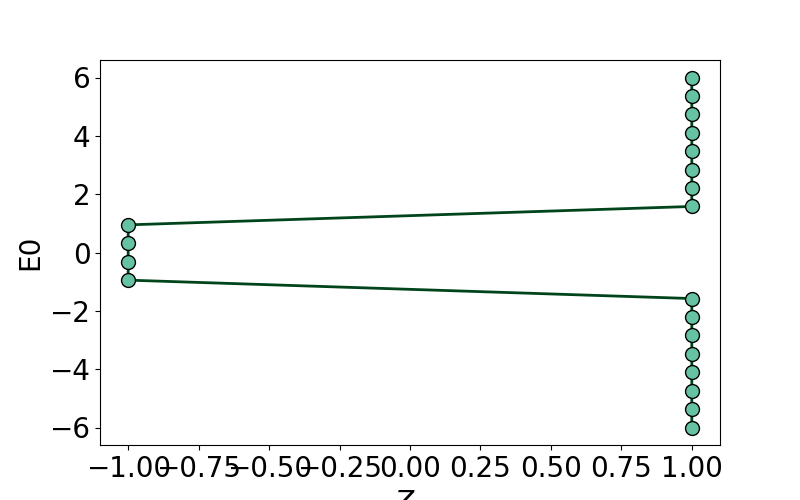

In [48]:
cmap = plt.get_cmap('BuGn')
plt.figure(figsize=(8,5));
plt.plot(dets,Er,'o-',markersize=10,linewidth=2,markeredgecolor='k',markerfacecolor=cmap(0.5),color=cmap(1.))
plt.ylabel('E0',fontsize=20)
plt.xlabel('$Z_2$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [23]:
#phase transition is at |M/t|=2


Er = np.linspace(-6,6,20)
dets = []
Len=5
m =1.5

p = dict(m =m, A = 1,B=1,kappa = 0.3)


for E0 in Er:
    p['E0'] = E0
    
    syst = system_2DBHZ_d(Len, Len, p)    

    det =  spectral_localizer_AII2D(syst,p,X0=np.array([0,0]),Ls=2*Len,flatten=True)

    dets.append(det)

    
    

m/2B: 1.5
E0: -6.0 x0,y0: 0 0 kappa: 0.3 W: 0
1.7763568394002505e-15
Pfaffian sign: 1.0
m/2B: 1.5
E0: -5.368421052631579 x0,y0: 0 0 kappa: 0.3 W: 0
1.6583956430338276e-15
Pfaffian sign: 1.0
m/2B: 1.5
E0: -4.7368421052631575 x0,y0: 0 0 kappa: 0.3 W: 0
1.7763568394002505e-15
Pfaffian sign: 1.0
m/2B: 1.5
E0: -4.105263157894737 x0,y0: 0 0 kappa: 0.3 W: 0
1.7763568394002505e-15
Pfaffian sign: 1.0
m/2B: 1.5
E0: -3.473684210526316 x0,y0: 0 0 kappa: 0.3 W: 0
1.7763568394002505e-15
Pfaffian sign: 1.0
m/2B: 1.5
E0: -2.8421052631578947 x0,y0: 0 0 kappa: 0.3 W: 0
1.6583956430338276e-15
Pfaffian sign: 1.0
m/2B: 1.5
E0: -2.210526315789474 x0,y0: 0 0 kappa: 0.3 W: 0
1.6583956430338276e-15
Pfaffian sign: 1.0
m/2B: 1.5
E0: -1.578947368421053 x0,y0: 0 0 kappa: 0.3 W: 0
1.6583956430338276e-15
Pfaffian sign: 1.0
m/2B: 1.5
E0: -0.9473684210526319 x0,y0: 0 0 kappa: 0.3 W: 0
1.6583956430338276e-15
Pfaffian sign: -1.0
m/2B: 1.5
E0: -0.3157894736842106 x0,y0: 0 0 kappa: 0.3 W: 0
1.6583956430338276e-15
Pfaffian

In [27]:

cmap = plt.get_cmap('BuGn')
plt.figure(figsize=(8,5));
plt.plot(dets,Er,'o-',markersize=10,linewidth=2,markeredgecolor='k',markerfacecolor=cmap(0.5),color=cmap(1.))
plt.xlabel('$Z_2$',fontsize=10)
plt.ylabel('$E$',fontsize=10)
plt.xticks(fontsize=10)
plt.title(' Flatten hamiltonian, m = 1.5')
plt.yticks(fontsize=10)
plt.show()

### Phase transition via Anderson's disorder

Disorder we should add? let us check the bands


m/2B: 1.5


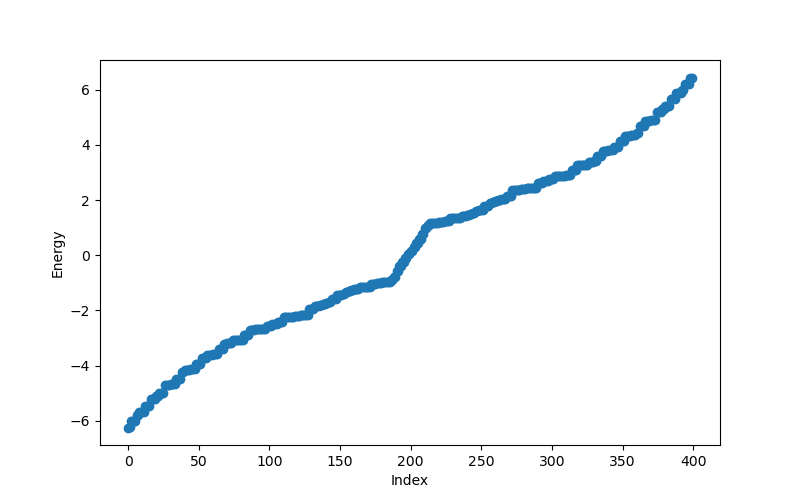

In [61]:
import scipy.linalg as spl

%matplotlib widget

def spectrum(sys):
    fsys = sys.finalized() 
    h = fsys.hamiltonian_submatrix(params = p)
    evals= spl.eigvalsh(h)
    plt.figure(figsize=(8,5));
    py.scatter(range(len(evals)), evals)
    py.xlabel('Index')
    py.ylabel('Energy')
    py.show()

length = 5
p = dict(m = 1.5, B = 1, A =1)
syst = system_2DBHZ_d(length, length, p)

spectrum(syst)

https://journals-aps-org.sid2nomade-1.grenet.fr/prb/pdf/10.1103/PhysRevB.109.L201102

https://iopscience.iop.org/article/10.1088/1742-6596/400/4/042070/pdf

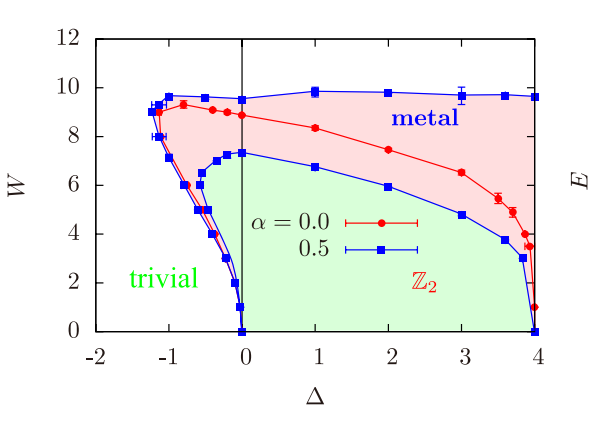

In the sti phase, some states start to trivialize at W > 2 (remember max value is W/2 = 1), since it is the size of the gap

In [2]:
length=5
p = dict(m = 1.5, A= 1, B =1,num_reals=20,W=4,E0=0)
syst = system_2DBHZ_d(length, length, p)

det = spectral_localizer_AII2D(syst,p,X0=np.array([0,0]),Ls=2*length);

m/2B: 1.5
E0: 0 x0,y0: 0 0 kappa: 0.9 W: 4
Averaging over realizations...
Percent: [#-------------------] 5.0% Realization Pfaffian: -1.0
Percent: [##------------------] 10.0% Realization Pfaffian: -1.0
Percent: [###-----------------] 15.0% Realization Pfaffian: -1.0
Percent: [####----------------] 20.0% Realization Pfaffian: 1.0
Percent: [#####---------------] 25.0% Realization Pfaffian: -1.0
Percent: [######--------------] 30.0% Realization Pfaffian: -1.0
Percent: [#######-------------] 35.0% Realization Pfaffian: -1.0
Percent: [########------------] 40.0% Realization Pfaffian: -1.0
Percent: [#########-----------] 45.0% Realization Pfaffian: -1.0
Percent: [##########----------] 50.0% Realization Pfaffian: -1.0
Percent: [###########---------] 55.0% Realization Pfaffian: -1.0
Percent: [############--------] 60.0% Realization Pfaffian: 1.0
Percent: [#############-------] 65.0% Realization Pfaffian: 1.0
Percent: [##############------] 70.0% Realization Pfaffian: -1.0
Percent: [##########

In [3]:
length=5
p = dict(m = 1.5, A= 1, B =1,num_reals=20,W=1.5,E0=-0.6)
syst = system_2DBHZ_d(length, length, p)
det_list = []
W_E0_det = {}

for W in np.linspace(4,10,5):

    p['W'] = W
    det_list = []

    for E0 in np.linspace(0,1,10):
        p['E0'] = E0
        det = spectral_localizer_AII2D(syst,p,X0=np.array([0,0]),Ls=2*length);
        det_list.append(det)

    W_E0_det[W] = det_list

m/2B: 1.5
E0: 0.0 x0,y0: 0 0 kappa: 0.9 W: 4.0
Averaging over realizations...
Percent: [#-------------------] 5.0% Realization Pfaffian: -1.0
Percent: [##------------------] 10.0% Realization Pfaffian: -1.0
Percent: [###-----------------] 15.0% Realization Pfaffian: -1.0
Percent: [####----------------] 20.0% Realization Pfaffian: 1.0
Percent: [#####---------------] 25.0% Realization Pfaffian: -1.0
Percent: [######--------------] 30.0% Realization Pfaffian: -1.0
Percent: [#######-------------] 35.0% Realization Pfaffian: -1.0
Percent: [########------------] 40.0% Realization Pfaffian: -1.0
Percent: [#########-----------] 45.0% Realization Pfaffian: -1.0
Percent: [##########----------] 50.0% Realization Pfaffian: -1.0
Percent: [###########---------] 55.0% Realization Pfaffian: -1.0
Percent: [############--------] 60.0% Realization Pfaffian: 1.0
Percent: [#############-------] 65.0% Realization Pfaffian: 1.0
Percent: [##############------] 70.0% Realization Pfaffian: -1.0
Percent: [######

In [5]:
%matplotlib qt

Er = np.linspace(0,1,10)

plt.figure()

for W in  np.linspace(4,10,5):

    detlist = W_E0_det[W]


    plt.scatter(W*np.ones(len(Er)),Er,c=detlist, cmap = 'viridis_r', vmax=1 , vmin=-1 , marker = 's',s=5000)
    plt.ylabel('E')
    plt.xlabel('W')
    plt.title('BHZ model')
plt.colorbar()

In the trivial phase (M=2.5), states in the bulk gap are 0.5~0.7 respect to 0, we should see some trivialization in W = 1 (W/2 = 0.5)

m/2B: 0.1
nan nan


C:\Users\Laura\AppData\Local\Temp\ipykernel_15792\1795265266.py:219: RuntimeWarning: invalid value encountered in divide
  wf = wf/number_of_states


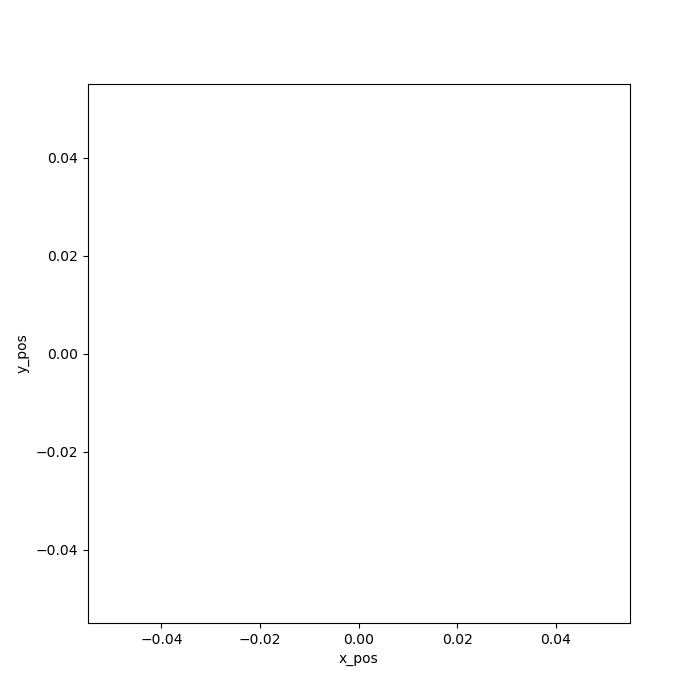

The number of states in this range is 0


In [87]:
length=5
p = dict(m = 0.1, A=1,B=1,num_reals=20,W=5)
syst = system_2DBHZ_d(length, length, p)

fsyst = syst.finalized()
ham = fsyst.hamiltonian_submatrix()

W =  p['W']
disp = np.diag(np.random.uniform(low=-W/2,high=W/2,size=len(fsyst.sites)))
AND_disorder = np.kron(disp,np.eye(4))
h = ham + AND_disorder

evals,evecs = spl.eigh(h)


Plot_DOS_2D(Emin=-0.05,Emax=0.05,fsyst=fsyst,evals=evals,evecs=evecs,p=dict(norbs=4))


In [10]:
for i in np.linspace(0,11,20):
    print(i)

0.0
0.5789473684210527
1.1578947368421053
1.736842105263158
2.3157894736842106
2.8947368421052633
3.473684210526316
4.052631578947368
4.631578947368421
5.210526315789474
5.7894736842105265
6.368421052631579
6.947368421052632
7.526315789473685
8.105263157894736
8.68421052631579
9.263157894736842
9.842105263157896
10.421052631578949
11.0


In [9]:
length=5
p = dict(m = 0.1, A= 1, B =1,num_reals=20,W=1.5,E0=-0.6,kappa=0.1)
syst = system_2DBHZ_d(length, length, p)
det_list = []
W_E0_det = {}

for W in [9,10]:

    p['W'] = W
    det_list = []

    for E0 in np.linspace(0,1,10):
        p['E0'] = E0
        det = spectral_localizer_AII2D(syst,p,X0=np.array([0,0]),Ls=2*length);
        det_list.append(det)

    W_E0_det[W] = det_list

m/2B: 0.1
E0: 0.0 x0,y0: 0 0 kappa: 0.1 W: 9
Averaging over realizations...
Percent: [#-------------------] 5.0% 

Realization Pfaffian: -1.0
Percent: [##------------------] 10.0% Realization Pfaffian: -1.0
Percent: [###-----------------] 15.0% Realization Pfaffian: -1.0
Percent: [####----------------] 20.0% Realization Pfaffian: -1.0
Percent: [#####---------------] 25.0% Realization Pfaffian: -1.0
Percent: [######--------------] 30.0% Realization Pfaffian: -1.0
Percent: [#######-------------] 35.0% Realization Pfaffian: -1.0
Percent: [########------------] 40.0% Realization Pfaffian: -1.0
Percent: [#########-----------] 45.0% Realization Pfaffian: 1.0
Percent: [##########----------] 50.0% Realization Pfaffian: 1.0
Percent: [###########---------] 55.0% Realization Pfaffian: 1.0
Percent: [############--------] 60.0% Realization Pfaffian: -1.0
Percent: [#############-------] 65.0% Realization Pfaffian: -1.0
Percent: [##############------] 70.0% Realization Pfaffian: -1.0
Percent: [###############-----] 75.0% Realization Pfaffian: -1.0
Percent: [################----] 80.0% Realization Pfaffian: -1.0
P

KeyboardInterrupt: 

## Plots

W vs m

(-1.0, 4.0)

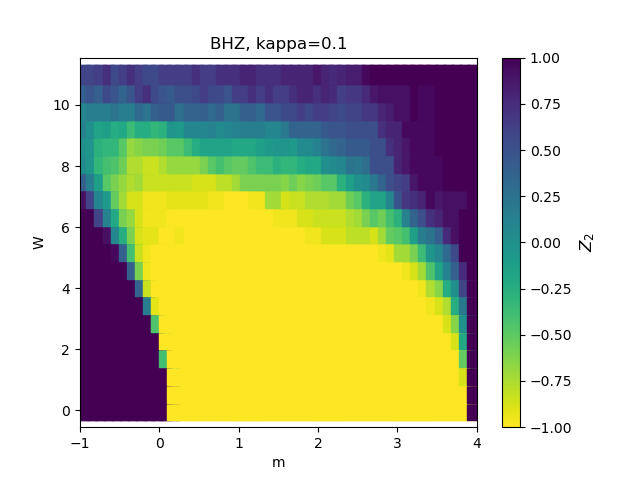

In [34]:
def extract_list(name_file):
    with open(name_file, 'r') as file:
        inside = file.readlines()  
        list = [np.real(line.strip()) for line in inside]
    return list



Wr = np.linspace(0,11,20)


m_range = np.linspace(-1,4,50)

Z2_list = []

for W in Wr[:19]:
        #Windows
        # Z2 = Z2_list.append(extract_list(r"C:\Users\Laura\Desktop\THESIS\bismuth\github\Bismuth-project\codes\plots\flow\L10_m2_2_vs_W_0_6_30reals_kappa005\ap5.1h10.5_E"+str(round(E0,2))+"_W0.0_6.0_reals30_kappa0.05.txt"))
        #Linux :
        Z2 = Z2_list.append(extract_list(f"/home/lauragomezpaz/Desktop/Bismuth-project/codes/plots/bhz_data/W{W}_m-1.0_4.0_reals50.txt"))

Z2_list.append(extract_list(f"/home/lauragomezpaz/Desktop/Bismuth-project/codes/plots/bhz_data/W11_m-1.0_4.0_reals50.txt"))

vmax = max([x for xs in Z2_list for x in xs])
vmin = min([x for xs in Z2_list for x in xs])

fig, ax = plt.subplots()

# plt.title(r'Z2 BHZ', ' X0 : gc')

for i,W in enumerate(Wr):

    colormap = Z2_list[i]

    plt.scatter(m_range,np.ones(len(m_range))*W,vmin=-1,vmax=1,c=colormap,cmap=cm.viridis_r,marker='s',s=200)

plt.title('BHZ, kappa=0.1')


cbar = plt.colorbar()
cbar.set_label("$Z_2$", fontsize=12)


plt.ylabel('W')
plt.xlabel('m')
# plt.ylim([min(Wr),max(r)])plt.show()
plt.xlim([-1,4])

E vs W

Text(0.5, 0, 'E')

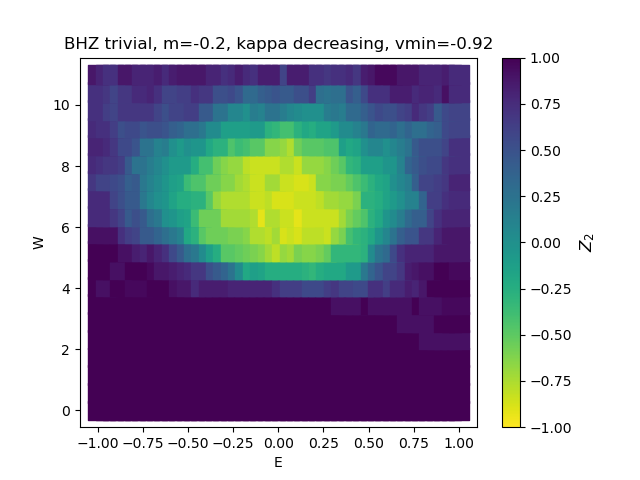

In [153]:
def extract_list(name_file):
    with open(name_file, 'r') as file:
        inside = file.readlines()  
        list = [np.real(line.strip()) for line in inside]
    return list



Wr = np.linspace(0,11,20)


E_range = np.linspace(-1,1,50)

Z2_list = []

for W in Wr[:19]:
        #Windows
        # Z2 = Z2_list.append(extract_list(r"C:\Users\Laura\Desktop\THESIS\bismuth\github\Bismuth-project\codes\plots\flow\L10_m2_2_vs_W_0_6_30reals_kappa005\ap5.1h10.5_E"+str(round(E0,2))+"_W0.0_6.0_reals30_kappa0.05.txt"))
        #Linux :
        Z2 = Z2_list.append(extract_list(f"/home/lauragomezpaz/Desktop/Bismuth-project/codes/plots/bhz_data/kappa_decreasing/W{W}_m-0.2_E-1.0_1.0_reals50_length5.txt"))

Z2_list.append(extract_list(f"/home/lauragomezpaz/Desktop/Bismuth-project/codes/plots/bhz_data/kappa_decreasing/W{11}_m-0.2_E-1.0_1.0_reals50_length5.txt"))

vmax = max([float(x) for xs in Z2_list for x in xs])
vmin = min([float(x) for xs in Z2_list for x in xs])

fig, ax = plt.subplots()


for i,W in enumerate(Wr):

    colormap = Z2_list[i]

    plt.scatter(E_range,np.ones(len(m_range))*W,vmin=-1,vmax=1,c=colormap,cmap=cm.viridis_r,marker='s',s=200)

plt.title(f'BHZ trivial, m=-0.2, kappa decreasing, vmin={vmin}')


cbar = plt.colorbar()
cbar.set_label("$Z_2 $", fontsize=12)


plt.ylabel('W')
plt.xlabel('E')
# plt.ylim([min(Wr),max(r)])plt.show()
# plt.xlim([-1,4])

m/2B: 0.1
200 -0.01465928595679769
201 -0.014659285956797248
0.0323153165685258 -3.4322139639814915


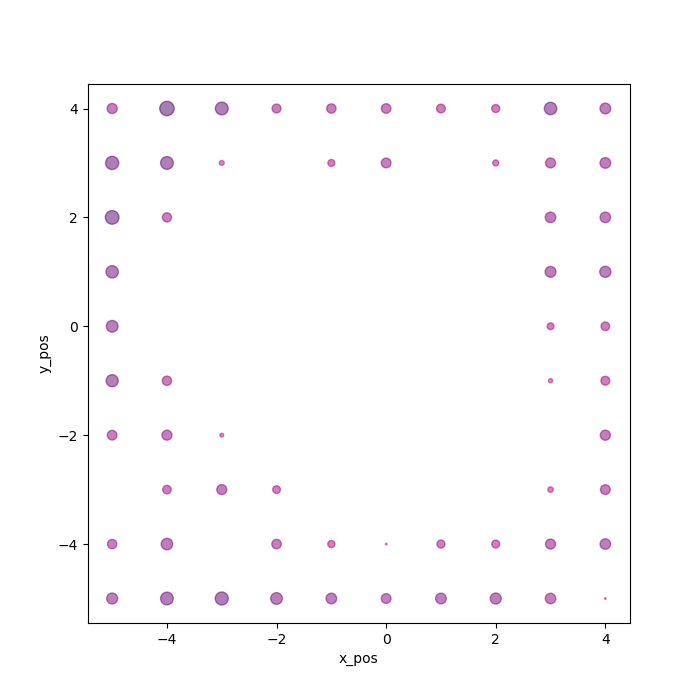

The number of states in this range is 2


In [94]:
length=5
p = dict(m = 0.1, A=1,B=1,num_reals=20,W=6)
syst = system_2DBHZ_d(length, length, p)

fsyst = syst.finalized()
ham = fsyst.hamiltonian_submatrix()

W =  p['W']
disp = np.diag(np.random.uniform(low=-W/2,high=W/2,size=len(fsyst.sites)))
AND_disorder = np.kron(disp,np.eye(4))
h = ham + AND_disorder

evals,evecs = spl.eigh(h)


Plot_DOS_2D(Emin=-0.1,Emax=0.1,fsyst=fsyst,evals=evals,evecs=evecs,p=dict(norbs=4))


<>:6: SyntaxWarning: invalid escape sequence '\k'
<>:6: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_552041/2543874493.py:6: SyntaxWarning: invalid escape sequence '\k'
  plt.ylabel('$\kappa$')


Text(0, 0.5, '$\\kappa$')

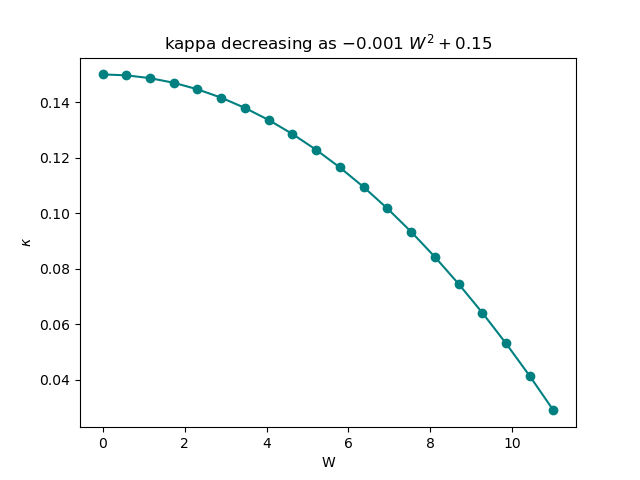

In [149]:
plt.figure()
Wr = np.linspace(0,11,20)
plt.plot(Wr,-(Wr**2)*0.001 + 0.15,marker='o',c='teal')
plt.title('kappa decreasing as $-0.001~W^2   + 0.15$')
plt.xlabel('W')
plt.ylabel('$\kappa$')